# Agentic RAG
🤖 What is Agentic RAG?

Agentic RAG stands for Agentic Retrieval-Augmented Generation — an advanced version of RAG where instead of a static, one-shot LLM response,the system uses an agent that:

- reasons,
- plans,
- retrieves,
- uses tools,
- and even retries or reflects
to generate better, more grounded answers.

# Topics Covered:


### 1. Basic Agentic RAG

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [23]:
from typing import List, Annotated
from pydantic import BaseModel
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.chains import create_retrieval_chain
from langchain.prompts import ChatPromptTemplate
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain.schema import Document
from langgraph.graph import StateGraph, END
from IPython.display import Image, display

In [5]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

In [20]:
llm=init_chat_model("openai:gpt-4o")

In [12]:
# -----------------------------
# 1. Document Preprocessing
# -----------------------------
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/"
]

loaders = [WebBaseLoader(url) for url in urls]
docs = []
for loader in loaders:
    docs.extend(loader.load())


print(f"📋 loaded {len(docs)} documents!")
print("="*60)
print(f"Content preview: {docs[0].page_content[0:1000].replace('\n', '')}...")
print("="*60)
print()
print(f"Metadata preview: {docs[0].metadata}")

📋 loaded 2 documents!
Content preview: LLM Powered Autonomous Agents | Lil'LogLil'Log|PostsArchiveSearchTagsFAQ      LLM Powered Autonomous Agents    Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng Table of ContentsAgent System OverviewComponent One: PlanningTask DecompositionSelf-ReflectionComponent Two: MemoryTypes of MemoryMaximum Inner Product Search (MIPS)Component Three: Tool UseCase StudiesScientific Discovery AgentGenerative Agents SimulationProof-of-Concept ExamplesChallengesCitationReferencesBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver....

Metadata preview: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered 

In [14]:
## Recursive character text ssplitter an vectorstore
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
split_docs = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(split_docs, embedding)
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 3})

In [15]:
# the invoke method will give you the documents related to the query
retriever.invoke("What are agents")

[Document(id='057a8502-91cb-490b-a6b7-0324836b8f56', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [16]:
# -----------------------------
# 2. Define RAG State
# -----------------------------
class RAGState(BaseModel):
    question: str
    retrieved_docs: List[Document] = []
    answer: str = ""

In [26]:
# -----------------------------
# 3. LangGraph Nodes
# -----------------------------
def retrieve_docs(state: RAGState) -> RAGState:
    docs = retriever.invoke(state.question)
    return RAGState(question=state.question, retrieved_docs=docs)

def generate_answer(state: RAGState) -> RAGState:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"Answer the question based on the context.\n\nContext:\n{context}\n\nQuestion: {state.question}"
    response = llm.invoke(prompt)
    return RAGState(question=state.question, retrieved_docs=state.retrieved_docs, answer= response.content) # type: ignore

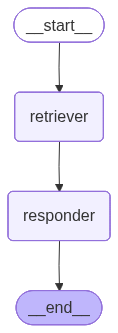

In [27]:
# -----------------------------
# 4. Build LangGraph
# -----------------------------

builder = StateGraph(RAGState)

builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)

builder.set_entry_point("retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
# -----------------------------
# 5. Run the Agentic RAG
# -----------------------------
user_question = "What is the concept of agent loop in autonomous agents?"
initial_state = RAGState(question=user_question)
final_state = graph.invoke(initial_state)
print("\n✅ Final Answer:\n", final_state['answer'])


✅ Final Answer:
 The concept of an agent loop in autonomous agents refers to the iterative process through which these agents operate, allowing them to continuously perceive, act, and learn from their environment. This cycle typically involves components such as memory, planning, action, and self-reflection. Memory lets the agent use past experiences to inform current decisions. Planning involves strategizing future actions to achieve specific goals. Self-reflection allows the agent to assess and learn from its previous decisions to improve future performance. Through this loop, agents can adapt their behavior over time, facilitating tasks such as scientific discovery or complex problem-solving, as they can refine their actions and correct mistakes in a dynamic and evolving context.


### 2. 🤖 Implement ReAct with LangGraph

ReAct (Reasoning + Acting) is a framework where an LLM:

- Reasons step-by-step (e.g. decomposes questions, makes decisions)

- Acts by calling tools like search, calculators, or retrievers

This makes it perfect for Agentic RAG:
✅ Think → Retrieve → Observe → Reflect → Final Answer

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langgraph.prebuilt import create_react_agent
from langchain.agents import Tool
from langchain.tools import WikipediaQueryRun
from langchain.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langgraph.graph import END, StateGraph
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model

In [6]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

In [30]:
# --------------------------
# 1. Create Retriever Tool
# --------------------------

# Load content from blog
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 3})

In [37]:
for doc in retriever.invoke("what are autonomous agents"):
    print(doc.id)
    print("="*60)
    print(f"{doc.page_content[0:1000]}...")

1081dc22-e5e0-4958-bdad-1bf1e82af08f
Or
@article{weng2023agent,
  title   = "LLM-powered Autonomous Agents",
  author  = "Weng, Lilian",
  journal = "lilianweng.github.io",
  year    = "2023",
  month   = "Jun",
  url     = "https://lilianweng.github.io/posts/2023-06-23-agent/"
}
References#
[1] Wei et al. “Chain of thought prompting elicits reasoning in large language models.” NeurIPS 2022
[2] Yao et al. “Tree of Thoughts: Dliberate Problem Solving with Large Language Models.” arXiv preprint arXiv:2305.10601 (2023)....
d6a77f70-c36e-451c-a647-2bb342a564b2
Boiko et al. (2023) also looked into LLM-empowered agents for scientific discovery, to handle autonomous design, planning, and performance of complex scientific experiments. This agent can use tools to browse the Internet, read documentation, execute code, call robotics experimentation APIs and leverage other LLMs.
For example, when requested to "develop a novel anticancer drug", the model came up with the following reasoning steps:.

In [3]:
def retriever_tool_func(query: str) -> str:
    print("📚 Using RAGRetriever tool")
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

retriever_tool=Tool(
    name="RAGRetriever",
    description="Use this tool to fetch relevant knowledge base info",
    func=retriever_tool_func
)

print(retriever_tool.name)

RAGRetriever


In [4]:
# Wikipedia tool
wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper()) #type: ignore

In [7]:
llm=init_chat_model("openai:gpt-4o")

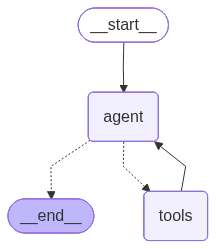

In [8]:
# ----------------------------
# 2. Define the Agent Node
# ----------------------------
tools = [retriever_tool, wiki_tool]
## create the native Langgraph react agent
react_node=create_react_agent(llm,tools)
react_node

In [9]:
# --------------------------
# 3. LangGraph Agent State
# --------------------------
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

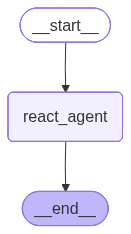

In [10]:
# --------------------------
# 4. Build LangGraph Graph
# --------------------------
builder = StateGraph(AgentState)
builder.add_node("react_agent", react_node)
builder.set_entry_point("react_agent")
builder.add_edge("react_agent", END)
graph = builder.compile()

graph

In [11]:
# --------------------------
# 5. Run the ReAct Agent
# --------------------------
user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
result = graph.invoke({"messages": [HumanMessage(content=user_query)]})
print("\n✅ Final Answer:\n", result["messages"][-1].content)

📚 Using RAGRetriever tool

✅ Final Answer:
 It seems there was an error retrieving information about the "agent loop in multi-agent systems" from the RAGRetriever. However, I can provide you with information from Wikipedia about autonomous agents.

### Autonomous Agents:
An autonomous agent is an artificial intelligence (AI) system capable of performing complex tasks independently. In the field of AI, these agents can perceive their environment, take actions autonomously to achieve goals, and may improve their performance through machine learning or by acquiring knowledge. Here are a few key points about autonomous and intelligent agents:

- **Intelligent Agents:** These are entities that perceive their environment and act autonomously to achieve specific goals. They may range from simple systems like thermostats to complex organisms like humans or sophisticated AI systems.

- **Agentic AI:** A subset of intelligent agents, these agents proactively pursue goals, make decisions, and tak

### 3. Tool creation for RAG agents with langgraph 
To create tools for RAG agents using LangGraph, you're essentially building LLM-invocable functions that your agent can call as part of its reasoning + acting loop (ReAct).

LangGraph uses the Tool abstraction from LangChain and fully supports tools for:

- RAG retrieval
- Search
- Wikipedia
- SQL
- Web APIs
- Calculators, etc.

#### ✅ Tool Design Requirements
A LangGraph tool must:

- Have a name
- Have a description (used by the LLM to decide when to use it)
- Have a callable func, accepting a single input (usually str) and returning str